In [2]:
import pymcel as pc
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
#Creamos la simulación
sim = rb.Simulation()

fecha_inicio = '2029-01-01'

sim.add('Sun', date=fecha_inicio)

# El código 399 forzará a Horizons a devolver las coordenadas puras del Geocentro (Tierra) 
# El código 301 forzará a Horizons a devolver las coordenadas puras de la Luna (evitando el baricentro)
sim.add('399', date=fecha_inicio, hash='Earth')  # Tierra
sim.add('301', date=fecha_inicio, hash='Moon')   # Luna
sim.add('JWST', date=fecha_inicio)  
sim.add('Jupiter', date=fecha_inicio)  
sim.add('Saturn', date=fecha_inicio)  
sim.add('Apophis', date=fecha_inicio, m = 3.06e-20)  # Asignamos masa a Apophis para que su gravedad sea real


In [20]:
# Estado heliocéntrico de Apophis (respecto al Sol)
p_sol = sim.particles[0]
p_apo = sim.particles[6]  # Apophis

r_vec = np.array([p_apo.x - p_sol.x, p_apo.y - p_sol.y, p_apo.z - p_sol.z]) # Vector de posición relativa de Apophis respecto al Sol
v_vec = np.array([p_apo.vx - p_sol.vx, p_apo.vy - p_sol.vy, p_apo.vz - p_sol.vz]) # Vector de velocidad relativa de Apophis respecto al Sol
mu = sim.G * (p_sol.m + p_apo.m) # mu de apophis y el sol

r = np.linalg.norm(r_vec) # Módulo del vector de posición relativa
v = np.linalg.norm(v_vec) # Módulo del vector de velocidad relativa

h_vec = np.cross(r_vec, v_vec) # Vector de MARE
h = np.linalg.norm(h_vec) # Módulo del vector de MARE

z = np.array([0.0, 0.0, 1.0]) # Vector unitario en Z

p = h**2 / mu # semilatus rectum de la órbita

n_vec = np.cross(z, h_vec) # Vector nodo 
n = np.linalg.norm(n_vec) # Módulo del vector nodo

e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r # Vector de Laplace
e = np.linalg.norm(e_vec) # Excentricidad

energy = v**2 / 2 - mu / r # ERE
a = -mu / (2 * energy) # Semieje mayor

i = np.arccos(h_vec[2] / h) * 180 / np.pi # Inclinación de la órbita de Apophis respecto al plano de referencia (eclíptica)

Omegap = np.arccos(n_vec[1] / n) * 180 / np.pi # Longitud del nodo ascendente

if n_vec[1] < 0: # Condición para determinar el cuadrante correcto de Omega
        Omega = 360.0 - Omegap
else:        
        Omega = Omegap

omegap = np.arccos(np.dot(n_vec, e_vec) / (n * e)) * 180 / np.pi # Argumento del perihelio

if e_vec[2] < 0:
        omega = 360.0 - omegap
else:        
        omega = omegap

fp = np.arccos(np.dot(e_vec, r_vec) / (e * r)) * 180 / np.pi # Anomalía verdadera

if np.dot(r_vec, e_vec)/r < 0:
    f = 360.0 - fp
else:
    f = fp


q = a * (1 - e) # periapsis  
Q = a * (1 + e) # Apoapsis

elementos = {
        "a [AU]": a,
        'p' : p,
        "e": e,
        "i":(i),
        "Omega":(Omega),
        "omega":(omega),
        "f": f,
        "q [AU]": q,
        "Q [AU]": Q,
    }

print("Elementos orbitales de Apophis (cálculo clásico):")
for k, val in elementos.items():
        print(f"{k:>24}: {val:.12g}")


Elementos orbitales de Apophis (cálculo clásico):
                  a [AU]: 0.922385646252
                       p: 0.888684289468
                       e: 0.191146972911
                       i: 3.3414594646
                   Omega: 246.125682383
                   omega: 126.695490626
                       f: 209.755748554
                  q [AU]: 0.746074422114
                  Q [AU]: 1.09869687039


In [23]:
tabla, jd, X = pc.consulta_horizons(
    id = 'Apophis',
    location = '@SSB',
    epochs = 2029-1-1 
)

X

array([-1.56649638e+11, -1.54565189e+10, -3.60203453e+09,  6.18288475e+03,
       -2.61376454e+04,  1.47485338e+03])

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'Pluto'... 

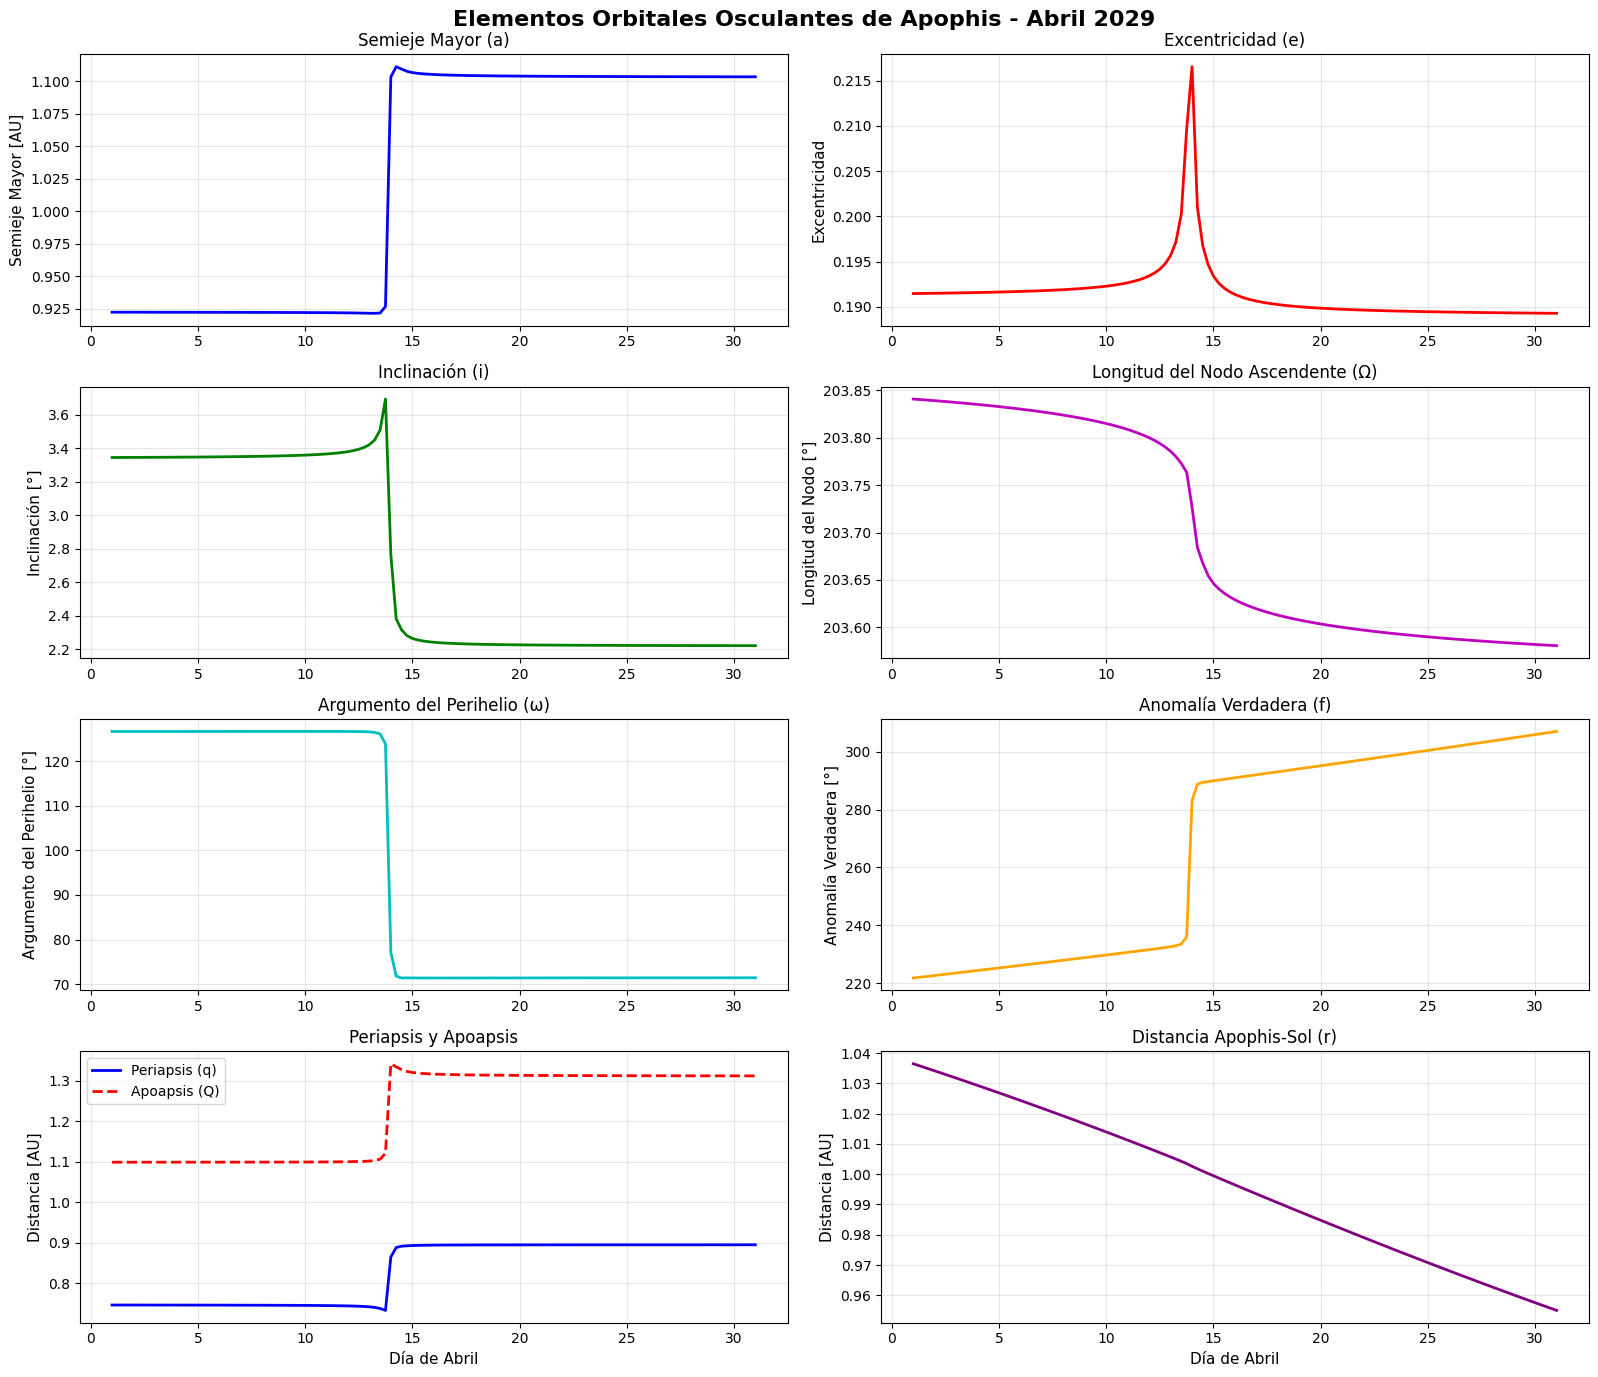


ELEMENTOS ORBITALES OSCULANTES DE APOPHIS - ABRIL 2029

Parámetro                      Inicial              Mínimo               Máximo              
------------------------------------------------------------------------------------------
Semieje Mayor [AU]             0.922187688359       0.921335961078       1.11122422732       
Excentricidad                  0.191481568472       0.189300865933       0.216530258562      
Inclinación [°]                3.34589508608        2.22243928275        3.69496741582       
Distancia al Sol [AU]          1.03645703575        0.955041338137       1.03645703575       

Distancia mínima: 0.955041338137 AU (142874184.19 km)
Ocurre el: 31.0 de abril


In [31]:
# Simulación de Apophis durante abril de 2029 con cálculo de elementos osculantes
fecha_inicio_abril = '2029-04-01'
fecha_fin_abril = '2029-04-30'

# Crear simulación
sim_abril_elem = rb.Simulation()
sim_abril_elem.add('Sun', date=fecha_inicio_abril)
sim_abril_elem.add('Mercury', date=fecha_inicio_abril)
sim_abril_elem.add('Venus', date=fecha_inicio_abril)
sim_abril_elem.add('399', date=fecha_inicio_abril, hash='Earth')
sim_abril_elem.add('301', date=fecha_inicio_abril, hash='Moon')
sim_abril_elem.add('Mars', date=fecha_inicio_abril)
sim_abril_elem.add('JWST', date=fecha_inicio_abril)
sim_abril_elem.add('Jupiter', date=fecha_inicio_abril)
sim_abril_elem.add('Saturn', date=fecha_inicio_abril)
sim_abril_elem.add('Uranus', date=fecha_inicio_abril)
sim_abril_elem.add('Neptune', date=fecha_inicio_abril)
sim_abril_elem.add('Pluto', date=fecha_inicio_abril)
sim_abril_elem.add('Apophis', date=fecha_inicio_abril, m=3.06e-20)
sim_abril_elem.move_to_com()

# Parámetros de integración
dias_abril = 30
N_puntos = 121  # Un punto cada 6 horas para mejor resolución
t_max_abril = (dias_abril / 365.25) * (2 * np.pi)
ts_abril_elem = np.linspace(0, t_max_abril, N_puntos)

# Listas para almacenar elementos orbitales
semieje_mayor = []
excentricidad = []
inclinacion = []
longitud_nodo = []
argumento_perihelio = []
anomalia_verdadera = []
periapsis = []
apoapsis = []
distancia_sol = []

# Integración y cálculo de elementos
for t in ts_abril_elem:
    sim_abril_elem.integrate(t)
    
    p_sol = sim_abril_elem.particles[0]
    # La partícula 12 es Apophis ahora (Sol=0, Merc=1, Ven=2, Tierra=3, Luna=4, Mars=5, JWST=6, Jup=7, Sat=8, Ura=9, Nep=10, Plu=11, Apo=12)
    p_apo = sim_abril_elem.particles[12]
    
    # Vectores posición y velocidad relativos al Sol
    r_vec = np.array([p_apo.x - p_sol.x, p_apo.y - p_sol.y, p_apo.z - p_sol.z])
    v_vec = np.array([p_apo.vx - p_sol.vx, p_apo.vy - p_sol.vy, p_apo.vz - p_sol.vz])
    
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)
    
    mu = sim_abril_elem.G * (p_sol.m + p_apo.m)
    
    # Elementos orbitales
    h_vec = np.cross(r_vec, v_vec)
    h = np.linalg.norm(h_vec)
    p = h**2 / mu
    
    energy = v**2 / 2 - mu / r
    a = -mu / (2 * energy)
    
    e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r
    e = np.linalg.norm(e_vec)
    
    z = np.array([0.0, 0.0, 1.0])
    n_vec = np.cross(z, h_vec)
    n = np.linalg.norm(n_vec)
    
    i = np.arccos(h_vec[2] / h) * 180 / np.pi
    
    Omega_p = np.arccos(n_vec[0] / n) * 180 / np.pi
    if n_vec[1] < 0:
        Omega = 360.0 - Omega_p
    else:
        Omega = Omega_p
    
    omega_p = np.arccos(np.dot(n_vec, e_vec) / (n * e)) * 180 / np.pi if (n > 0 and e > 0) else 0
    if e_vec[2] < 0:
        omega = 360.0 - omega_p
    else:
        omega = omega_p
    
    f_p = np.arccos(np.dot(e_vec, r_vec) / (e * r)) * 180 / np.pi if e > 0 else 0
    if np.dot(r_vec, v_vec) < 0:
        f = 360.0 - f_p
    else:
        f = f_p
    
    q = a * (1 - e)
    Q = a * (1 + e)
    
    # Almacenar
    semieje_mayor.append(a)
    excentricidad.append(e)
    inclinacion.append(i)
    longitud_nodo.append(Omega)
    argumento_perihelio.append(omega)
    anomalia_verdadera.append(f)
    periapsis.append(q)
    apoapsis.append(Q)
    distancia_sol.append(r)

# Convertir tiempo a días desde el 1 de abril
dias_desde_inicio = (ts_abril_elem / (2 * np.pi)) * 365.25

# Crear figura con múltiples subplots
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Elementos Orbitales Osculantes de Apophis - Abril 2029', fontsize=16, fontweight='bold')

# Semieje mayor
axes[0, 0].plot(dias_desde_inicio + 1, semieje_mayor, 'b-', linewidth=2)
axes[0, 0].set_ylabel('Semieje Mayor [AU]', fontsize=11)
axes[0, 0].set_title('Semieje Mayor (a)')
axes[0, 0].grid(True, alpha=0.3)

# Excentricidad
axes[0, 1].plot(dias_desde_inicio + 1, excentricidad, 'r-', linewidth=2)
axes[0, 1].set_ylabel('Excentricidad', fontsize=11)
axes[0, 1].set_title('Excentricidad (e)')
axes[0, 1].grid(True, alpha=0.3)

# Inclinación
axes[1, 0].plot(dias_desde_inicio + 1, inclinacion, 'g-', linewidth=2)
axes[1, 0].set_ylabel('Inclinación [°]', fontsize=11)
axes[1, 0].set_title('Inclinación (i)')
axes[1, 0].grid(True, alpha=0.3)

# Longitud del nodo ascendente
axes[1, 1].plot(dias_desde_inicio + 1, longitud_nodo, 'm-', linewidth=2)
axes[1, 1].set_ylabel('Longitud del Nodo [°]', fontsize=11)
axes[1, 1].set_title('Longitud del Nodo Ascendente (Ω)')
axes[1, 1].grid(True, alpha=0.3)

# Argumento del perihelio
axes[2, 0].plot(dias_desde_inicio + 1, argumento_perihelio, 'c-', linewidth=2)
axes[2, 0].set_ylabel('Argumento del Perihelio [°]', fontsize=11)
axes[2, 0].set_title('Argumento del Perihelio (ω)')
axes[2, 0].grid(True, alpha=0.3)

# Anomalía verdadera
axes[2, 1].plot(dias_desde_inicio + 1, anomalia_verdadera, 'orange', linewidth=2)
axes[2, 1].set_ylabel('Anomalía Verdadera [°]', fontsize=11)
axes[2, 1].set_title('Anomalía Verdadera (f)')
axes[2, 1].grid(True, alpha=0.3)

# Periapsis y Apoapsis
axes[3, 0].plot(dias_desde_inicio + 1, periapsis, 'b-', linewidth=2, label='Periapsis (q)')
axes[3, 0].plot(dias_desde_inicio + 1, apoapsis, 'r--', linewidth=2, label='Apoapsis (Q)')
axes[3, 0].set_ylabel('Distancia [AU]', fontsize=11)
axes[3, 0].set_xlabel('Día de Abril', fontsize=11)
axes[3, 0].set_title('Periapsis y Apoapsis')
axes[3, 0].legend(fontsize=10)
axes[3, 0].grid(True, alpha=0.3)

# Distancia al Sol
axes[3, 1].plot(dias_desde_inicio + 1, distancia_sol, 'purple', linewidth=2)
axes[3, 1].set_ylabel('Distancia [AU]', fontsize=11)
axes[3, 1].set_xlabel('Día de Abril', fontsize=11)
axes[3, 1].set_title('Distancia Apophis-Sol (r)')
axes[3, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir tabla resumen
print("\n" + "="*80)
print("ELEMENTOS ORBITALES OSCULANTES DE APOPHIS - ABRIL 2029")
print("="*80)
print(f"\n{'Parámetro':<30} {'Inicial':<20} {'Mínimo':<20} {'Máximo':<20}")
print("-"*90)
print(f"{'Semieje Mayor [AU]':<30} {semieje_mayor[0]:<20.12g} {min(semieje_mayor):<20.12g} {max(semieje_mayor):<20.12g}")
print(f"{'Excentricidad':<30} {excentricidad[0]:<20.12g} {min(excentricidad):<20.12g} {max(excentricidad):<20.12g}")
print(f"{'Inclinación [°]':<30} {inclinacion[0]:<20.12g} {min(inclinacion):<20.12g} {max(inclinacion):<20.12g}")
print(f"{'Distancia al Sol [AU]':<30} {distancia_sol[0]:<20.12g} {min(distancia_sol):<20.12g} {max(distancia_sol):<20.12g}")

# Encontrar día de máxima aproximación
idx_min_dist = np.argmin(distancia_sol)
print(f"\nDistancia mínima: {distancia_sol[idx_min_dist]:.12g} AU ({distancia_sol[idx_min_dist]*1.496e11/1000:.2f} km)")
print(f"Ocurre el: {dias_desde_inicio[idx_min_dist] + 1:.1f} de abril")

In [32]:
for i 

a = mu / (2 * mu / r - v**2)

plt.plot()

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for 'Moon'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Moon')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


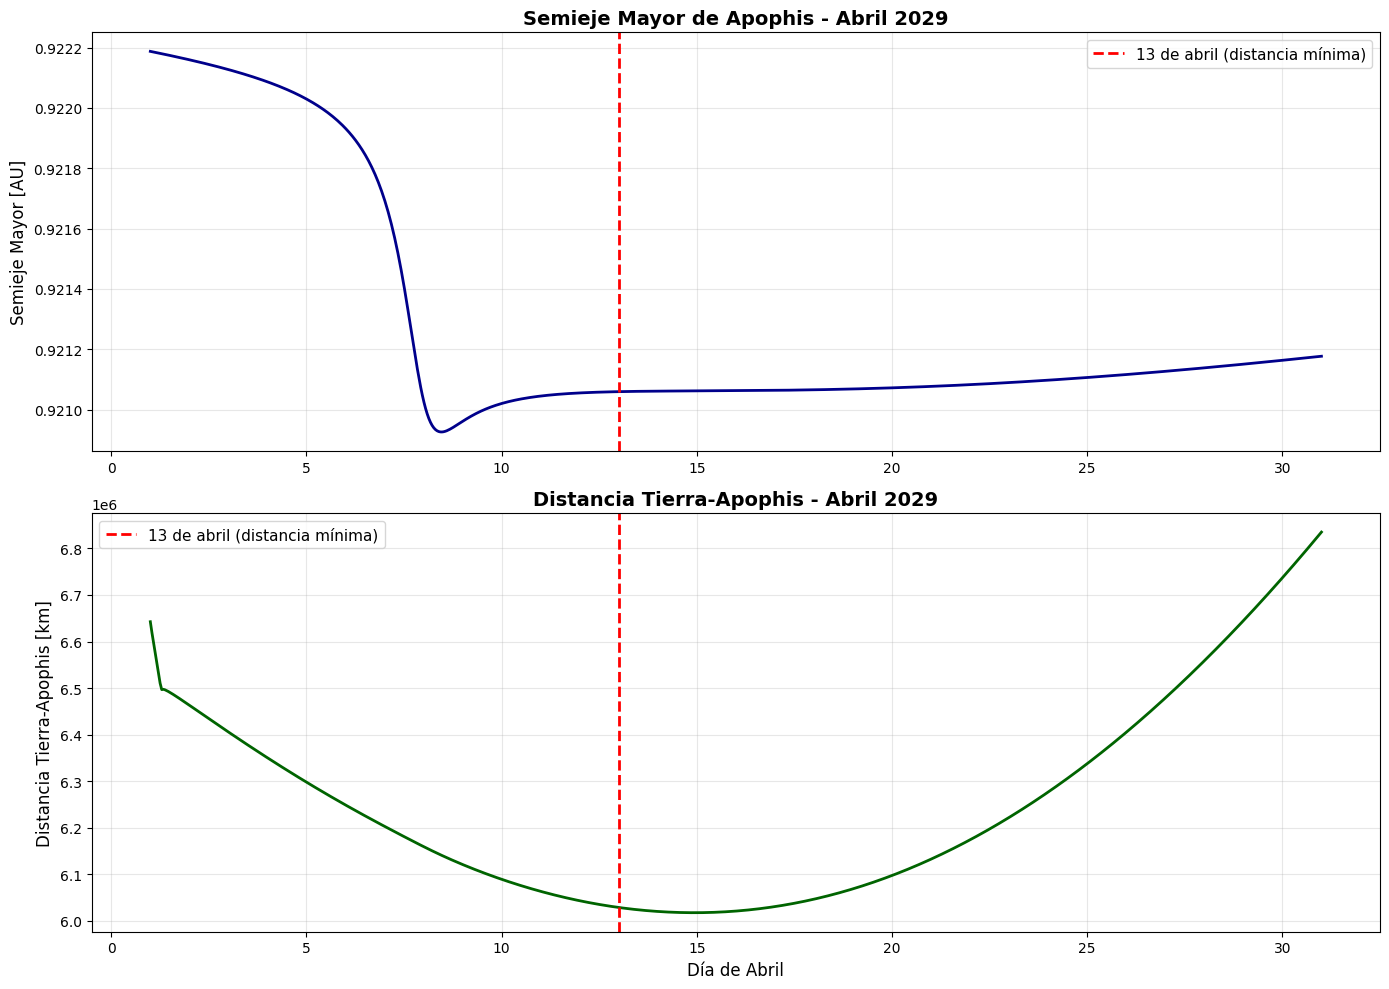


Información del 13 de abril (día de mínima distancia):
Semieje Mayor: 0.921059631399 AU
Distancia Tierra-Apophis: 0.0402981749973 AU (6028606.98 km)
Semieje Mayor día 1: 0.922187688359 AU
Cambio total en semieje mayor: -0.00101072335388 AU


In [28]:
# Simulación completa del sistema solar durante abril de 2029
fecha_inicio_abril = '2029-04-01'
fecha_fin_abril = '2029-04-30'

# Crear simulación con todos los planetas
sim_abril = rb.Simulation()
sim_abril.add('Sun', date=fecha_inicio_abril)
sim_abril.add('Mercury', date=fecha_inicio_abril)
sim_abril.add('Venus', date=fecha_inicio_abril)
sim_abril.add('399', date=fecha_inicio_abril, hash='Earth')
sim_abril.add('Moon', date=fecha_inicio_abril)
sim_abril.add('Mars', date=fecha_inicio_abril)
sim_abril.add('Jupiter', date=fecha_inicio_abril)
sim_abril.add('Saturn', date=fecha_inicio_abril)
sim_abril.add('Uranus', date=fecha_inicio_abril)
sim_abril.add('Neptune', date=fecha_inicio_abril)
sim_abril.add('Pluto', date=fecha_inicio_abril)
sim_abril.add('Apophis', date=fecha_inicio_abril, m=3.06e-20)
sim_abril.move_to_com()

# Parámetros de integración para abril (30 días)
dias_abril = 30
N_dias = 30 * 24  # Un punto cada hora para mayor resolución

# CORRECCIÓN: 1 año en unidades Rebound es 2*pi, no 1. 
t_max_abril = (dias_abril / 365.25) * (2 * np.pi)  
ts_abril = np.linspace(0, t_max_abril, N_dias)

# Vectores para almacenar resultados
semieje_mayor_abril = []
distancia_tierra_apophis = []
fechas_abril = []

# Integración
for i, t in enumerate(ts_abril):
    sim_abril.integrate(t)
    
    # Partículas
    p_sol = sim_abril.particles[0]
    p_tierra = sim_abril.particles[3]
    p_apophis = sim_abril.particles[11]
    
    # Vector de posición y velocidad de Apophis respecto al Sol
    r_vec = np.array([p_apophis.x - p_sol.x, p_apophis.y - p_sol.y, p_apophis.z - p_sol.z])
    v_vec = np.array([p_apophis.vx - p_sol.vx, p_apophis.vy - p_sol.vy, p_apophis.vz - p_sol.vz])
    
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)
    
    # Parámetro gravitacional
    mu = sim_abril.G * (p_sol.m + p_apophis.m)
    
    # Semieje mayor: a = mu / (2*mu/r - v^2)
    a = mu / (2 * mu / r - v**2)
    semieje_mayor_abril.append(a)
    
    # Distancia Tierra-Apophis
    r_tierra_apo = np.linalg.norm(np.array([p_apophis.x - p_tierra.x, 
                                             p_apophis.y - p_tierra.y, 
                                             p_apophis.z - p_tierra.z]))
    distancia_tierra_apophis.append(r_tierra_apo)

# Convertir ts_abril a días desde el 1 de abril (deshaciendo el factor 2*pi)
dias_desde_inicio = (ts_abril / (2 * np.pi)) * 365.25

# Crear figura con dos ejes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# El mínimo acercamiento de Apophis en 2029 es el 13 de Abril, no el 21!
dia_minimo = 13

# Gráfico 1: Semieje mayor
ax1.plot(dias_desde_inicio + 1, semieje_mayor_abril, linewidth=2, color='darkblue') # +1 para que cuadre con la fecha (1-30)
ax1.axvline(x=dia_minimo, color='red', linestyle='--', linewidth=2, label=f'{dia_minimo} de abril (distancia mínima)')
ax1.set_ylabel('Semieje Mayor [AU]', fontsize=12)
ax1.set_title('Semieje Mayor de Apophis - Abril 2029', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Gráfico 2: Distancia Tierra-Apophis
ax2.plot(dias_desde_inicio + 1, np.array(distancia_tierra_apophis) * 1.496e11 / 1000, 
         linewidth=2, color='darkgreen')
ax2.axvline(x=dia_minimo, color='red', linestyle='--', linewidth=2, label=f'{dia_minimo} de abril (distancia mínima)')
ax2.set_ylabel('Distancia Tierra-Apophis [km]', fontsize=12)
ax2.set_xlabel('Día de Abril', fontsize=12)
ax2.set_title('Distancia Tierra-Apophis - Abril 2029', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Imprimir información del día crítico (13 de Abril)
# Si empezamos el 1 (dias_desde_inicio=0) + 1 = 1, el 13 es 12 días después del inicio.
idx_dia_minimo = int(12 * 24)  
print(f"\nInformación del {dia_minimo} de abril (día de mínima distancia):")
print(f"Semieje Mayor: {semieje_mayor_abril[idx_dia_minimo]:.12g} AU")
print(f"Distancia Tierra-Apophis: {distancia_tierra_apophis[idx_dia_minimo]:.12g} AU ({distancia_tierra_apophis[idx_dia_minimo]*1.496e11/1000:.2f} km)")
print(f"Semieje Mayor día 1: {semieje_mayor_abril[0]:.12g} AU")
print(f"Cambio total en semieje mayor: {(semieje_mayor_abril[-1] - semieje_mayor_abril[0]):.12g} AU")

vamos a integrar la simulación, que comienza el primero de enero, durante 5 unidades de tiempo, que en términos de Rebound son aproximadamente 8 meses y medio, es decir, hasta mediados de agosto. Como el cometa pasa en abril, se cree que es un tiempo pertinente para observar todos los fenómenos deseados

In [6]:
N_pasos = 300 # Número de cuadros
t_max = 5 # 5 unidades de tiempo
ts = np.linspace(0, t_max, N_pasos) 

#Guardamos las posiciones y velocidades para los 13 cuerpos
x_inis = [[] for _ in range(13)]
y_inis = [[] for _ in range(13)]
z_inis = [[] for _ in range(13)]
vx_inis = [[] for _ in range(13)]
vy_inis = [[] for _ in range(13)]
vz_inis = [[] for _ in range(13)]

#Integramos la simulación
for t in ts:
    sim.integrate(t)
    
    # La Tierra ahora es la partícula 3 (Sol=0, Merc=1, Ven=2, Tierra=3)
    pos_tierra = sim.particles[3].xyz
    vel_tierra = sim.particles[3].vxyz

    for i, p in enumerate(sim.particles):
        # Guardamos posiciones relativas a la Tierra
        x_inis[i].append(p.x - pos_tierra[0])
        y_inis[i].append(p.y - pos_tierra[1])
        z_inis[i].append(p.z - pos_tierra[2])

        # De igual forma para las velocidades
        vx_inis[i].append(p.vx - vel_tierra[0])
        vy_inis[i].append(p.vy - vel_tierra[1])
        vz_inis[i].append(p.vz - vel_tierra[2])

In [7]:
nombres = ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'JWST', 'Júpiter', 'Saturno', 'Urano', 'Neptuno', 'Plutón', 'Apophis']
colores_planetas = ['#FFD700', 'gray', 'orange', 'blue', 'silver', 'red', 'purple', '#FF4500', '#DEB887', 'lightblue', 'blue', 'lightgray', '#FF0000']

limite = 0.05  # Limite fijo para enfocar bien Cislunar + JWST

paso_frame = max(1, N_pasos // 400) # Reducimos cantidad de frames para mejorar rendimiento

# ------------------- Configuración para los gráficos ------------------------------

layout_base = dict(
    width=860, height=760,
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis=dict(title="X [AU]", range=[-limite, limite]),
        yaxis=dict(title="Y [AU]", range=[-limite, limite]),
        zaxis=dict(title="Z [AU]", range=[-limite, limite]),
        # Es vital fijar aspectmode a 'cube' para que las órbitas no se distorsionen ni se aplasten
        aspectmode='cube',
        camera=dict(
            eye=dict(x=0.1, y=0.1, z=0.1) # El zoom lo ampliamos para que la caja 3D sea visible
        )
    ),
    updatemenus=[dict(
        type='buttons',
        direction="left",
        pad={"r": 10, "t": 87},
        showactive=True,
        x=0.1,
        xanchor="right",
        y=0,
        yanchor="top",
        buttons=[
            dict(label='▶ Play',
                method='animate',
                args=[None, dict(frame=dict(duration=40, redraw=True), 
                                fromcurrent=True, mode='immediate', transition=dict(duration=0))]), 
            dict(label='⏸ Pausa',
                method='animate',
                args=[[None], dict(frame=dict(duration=0, redraw=True),
                                    mode='immediate', transition=dict(duration=0))])
        ]
    )],
    sliders=[dict(
        active=0,
        yanchor="top",
        xanchor="left",
        currentvalue=dict(
            font=dict(size=14),
            prefix="Frame: ",
            visible=True,
            xanchor="right"
        ),
        transition=dict(duration=0), 
        pad=dict(b=10, t=50),
        len=0.9,
        x=0.1,
        y=0,
        steps=[dict(method='animate',
                    args=[[str(fi)], dict(mode='immediate',
                                        frame=dict(duration=0, redraw=True), transition=dict(duration=0))], 
                    label=str(fi))
            for fi in range(0, N_pasos, paso_frame)] 
    )]
)

# Trazo inicial: primero las órbitas y luego la animación de los cuerpos
trazos_base = []

# Primero agregamos las órbitas completas estáticas para los 13 cuerpos
for i in range(13):
    # Ocultamos la trayectoria de los cuerpos alejados por defecto para no ensuciar el acercamiento
    # JWST(6), Luna(4), Tierra(3), Apophis(12) visibles por defecto
    visible_val = True if i in [3, 4, 6, 12] else 'legendonly'
    
    trazos_base.append(
        go.Scatter3d(
            x=x_inis[i], 
            y=y_inis[i], 
            z=z_inis[i],
            mode='lines',
            line=dict(color=colores_planetas[i], width=2),
            name=f'Órbita {nombres[i]}',
            visible=visible_val
        )
    )

# Luego agregamos la burbuja inicial estática (animable)
# IMPORTANTE: Plotly indexa cada trazo. Hemos agregado 13 trazos de líneas (órbitas).
# Por tanto, este trazo de los marcadores ocupará SÓLO el índice 13.
trazos_base.append(
    go.Scatter3d(
        x=[x_inis[i][0] for i in range(13)],
        y=[y_inis[i][0] for i in range(13)],
        z=[z_inis[i][0] for i in range(13)],
        mode='markers+text',
        text=nombres, textposition="top center",
        marker=dict(size=4, color=colores_planetas),
        showlegend=False
    )
)

# Animación del sistema solar SÓLO inyectando cambios al trazo de índice 13
fig1 = go.Figure(
    data=trazos_base,
    frames=[go.Frame(
        name=str(k),
        data=[
            go.Scatter3d(
                x=[x_inis[i][k] for i in range(13)],
                y=[y_inis[i][k] for i in range(13)],
                z=[z_inis[i][k] for i in range(13)]
            )
        ],
        traces=[13]
    ) for k in range(0, N_pasos, paso_frame)]
)

fig1.update_layout(**layout_base)
fig1.update_layout(title="Acercamiento: Tierra, Luna, JWST y Apophis")
fig1.show()

Para medir la perturbación exacta que ejerce Apophis sobre el JWST, creamos dos simulaciones y comparamos la desviación en la trayectoria. 

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 


c:\Users\ASUS\Downloads\mecanica_cel\mecanicacelev\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


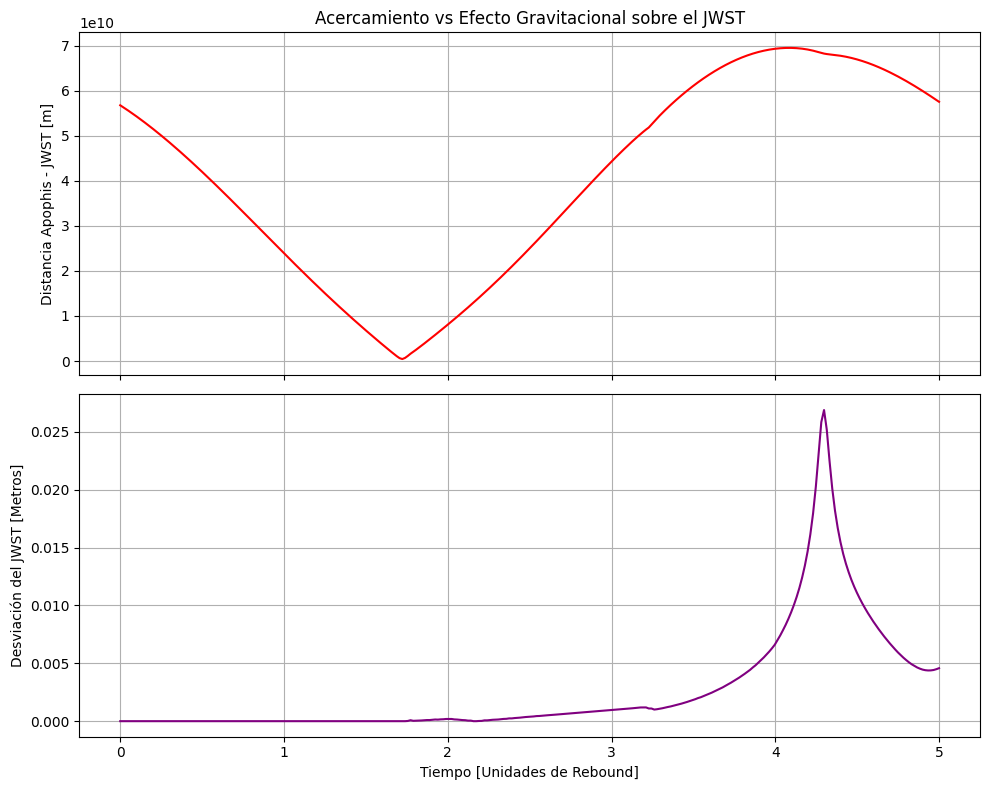

In [8]:
# --- SIMULACIÓN SIN APOPHIS ---
sim_sin = rb.Simulation()
sim_sin.add('Sun', date=fecha_inicio)
sim_sin.add('Mercury', date=fecha_inicio)
sim_sin.add('Venus', date=fecha_inicio)
sim_sin.add('399', date=fecha_inicio, hash='Earth')
sim_sin.add('301', date=fecha_inicio, hash='Moon')
sim_sin.add('Mars', date=fecha_inicio)
sim_sin.add('JWST', date=fecha_inicio)
sim_sin.add('Jupiter', date=fecha_inicio)
sim_sin.add('Saturn', date=fecha_inicio)
sim_sin.add('Uranus', date=fecha_inicio)
sim_sin.add('Neptune', date=fecha_inicio)
sim_sin.add('Pluto', date=fecha_inicio)

# --- SIMULACIÓN CON APOPHIS ---
sim_con = rb.Simulation()
sim_con.add('Sun', date=fecha_inicio)
sim_con.add('Mercury', date=fecha_inicio)
sim_con.add('Venus', date=fecha_inicio)
sim_con.add('399', date=fecha_inicio, hash='Earth')
sim_con.add('301', date=fecha_inicio, hash='Moon')
sim_con.add('Mars', date=fecha_inicio)
sim_con.add('JWST', date=fecha_inicio)
sim_con.add('Jupiter', date=fecha_inicio)
sim_con.add('Saturn', date=fecha_inicio)
sim_con.add('Uranus', date=fecha_inicio)
sim_con.add('Neptune', date=fecha_inicio)
sim_con.add('Pluto', date=fecha_inicio)
sim_con.add('Apophis', date=fecha_inicio)


# Vectores para guardar la desviación del JWST a lo largo del tiempo
desviacion_JWST = []
distancia_Apo_JWST = []

# Integramos ambas y comparamos
for t in ts:
    sim_sin.integrate(t)
    sim_con.integrate(t)
    
    # Obtenemos la partícula 6 (JWST) en ambas simulaciones (Sol=0, Mer=1, Ven=2, Tierra=3, Luna=4, Mars=5, JWST=6)
    pos_jwst_sin = np.array(sim_sin.particles[6].xyz)
    pos_jwst_con = np.array(sim_con.particles[6].xyz)
    
    # Calculamos la diferencia de posición (en Unidades Astronómicas)
    diferencia = np.linalg.norm(pos_jwst_con - pos_jwst_sin)
    desviacion_JWST.append(diferencia)
    
    # Adicionalmente calculamos la distancia entre Apophis (índice 12) y JWST
    pos_apo = np.array(sim_con.particles[12].xyz)
    distancia_Apo_JWST.append(np.linalg.norm(pos_apo - pos_jwst_con))

# Convertimos la desviación a un valor más legible, por ejemplo metros (1 AU ~ 1.496e11 metros)
desviacion_metros = np.array(desviacion_JWST) * 1.496e11
# Convertimos la distancia a metros (1 AU ~ 1.496e11 metros)
dist_m_array = np.array(distancia_Apo_JWST) * 1.496e11

# Gráfico del efecto
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(ts, dist_m_array, color='red')
ax1.set_ylabel('Distancia Apophis - JWST [m]')
ax1.set_title('Acercamiento vs Efecto Gravitacional sobre el JWST')
ax1.grid()

ax2.plot(ts, desviacion_metros, color='purple')
ax2.set_ylabel('Desviación del JWST [Metros]')
ax2.set_xlabel('Tiempo [Unidades de Rebound]')
ax2.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Variables para la animación "Microscópica"
escala_aumento = 1e20  # Factor para exagerar la desviación y poder verla
limite_jwst = 0.05    # Límite de visualización (Unidades Astronómicas alrededor del JWST)

# Vectores
x_jwst_fijo, y_jwst_fijo, z_jwst_fijo = [], [], []
x_jwst_desv, y_jwst_desv, z_jwst_desv = [], [], []
x_apo_rel, y_apo_rel, z_apo_rel = [], [], []

sim_sin = rb.Simulation()
sim_sin.add('Sun', date=fecha_inicio)
sim_sin.add('399', date=fecha_inicio, hash='Earth')
sim_sin.add('301', date=fecha_inicio, hash='Moon')
sim_sin.add('JWST', date=fecha_inicio)
sim_sin.add('Jupiter', date=fecha_inicio)
sim_sin.add('Saturn', date=fecha_inicio)

sim_con = rb.Simulation()
sim_con.add('Sun', date=fecha_inicio)
sim_con.add('399', date=fecha_inicio, hash='Earth')
sim_con.add('301', date=fecha_inicio, hash='Moon')
sim_con.add('JWST', date=fecha_inicio)
sim_con.add('Jupiter', date=fecha_inicio)
sim_con.add('Saturn', date=fecha_inicio)
sim_con.add('Apophis', date=fecha_inicio, m = 3.06e-10)

for t in ts:
    sim_sin.integrate(t)
    sim_con.integrate(t)
    
    p_jwst_sin = sim_sin.particles[3]
    p_jwst_con = sim_con.particles[3]
    p_apo_con = sim_con.particles[6]
    
    # El JWST original estará en el centro exacto (0,0,0)
    x_jwst_fijo.append(0)
    y_jwst_fijo.append(0)
    z_jwst_fijo.append(0)
    
    # El JWST perturbado es su diferencia multiplicada por la gran escala de aumento
    dx = (p_jwst_con.x - p_jwst_sin.x) * escala_aumento
    dy = (p_jwst_con.y - p_jwst_sin.y) * escala_aumento
    dz = (p_jwst_con.z - p_jwst_sin.z) * escala_aumento
    
    x_jwst_desv.append(dx)
    y_jwst_desv.append(dy)
    z_jwst_desv.append(dz)
    
    # La posición de Apophis será relativa al JWST "imperturbable" (el centro)
    # y la mostramos sin multiplicar! Es su distancia real respecto al telescopio.
    x_apo_rel.append(p_apo_con.x - p_jwst_sin.x)
    y_apo_rel.append(p_apo_con.y - p_jwst_sin.y)
    z_apo_rel.append(p_apo_con.z - p_jwst_sin.z)

# Configuración del gráfico centrado en JWST
layout_jwst = dict(
    width=800, height=700,
    scene=dict(
        xaxis=dict(title="X [AU]", range=[-limite_jwst, limite_jwst]),
        yaxis=dict(title="Y [AU]", range=[-limite_jwst, limite_jwst]),
        zaxis=dict(title="Z [AU]", range=[-limite_jwst, limite_jwst]),
        aspectmode='cube',
        camera=dict(
            eye=dict(x=0.1, y=0.1, z=0.1) # Zoom aplicado
        )
    ),
    updatemenus=[dict(type='buttons', direction="left", showactive=True, x=0.1, y=0,
        buttons=[
            dict(label='▶', method='animate', args=[None, dict(frame=dict(duration=20, redraw=True), mode='immediate')]),
            dict(label='⏸', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=True), mode='immediate')])
        ]
    )]
)

cuerpos_anim = ['JWST Normal', f'JWST Perturbado (Escala x{int(escala_aumento):.0E})', 'Apophis']
colores_anim = ['purple', 'cyan', 'red']

# Trazo inicial
trazo_jwst_anim = [
    go.Scatter3d(
        x=[x_jwst_fijo[0], x_jwst_desv[0], x_apo_rel[0]],
        y=[y_jwst_fijo[0], y_jwst_desv[0], y_apo_rel[0]],
        z=[z_jwst_fijo[0], z_jwst_desv[0], z_apo_rel[0]],
        mode='markers+text',
        text=cuerpos_anim, textposition="top center",
        marker=dict(size=[6, 5, 8], color=colores_anim)
    )
]

fig_jwst = go.Figure(
    data=trazo_jwst_anim,
    frames=[
        go.Frame(
            name=str(k),
            data=[go.Scatter3d(
                x=[x_jwst_fijo[k], x_jwst_desv[k], x_apo_rel[k]],
                y=[y_jwst_fijo[k], y_jwst_desv[k], y_apo_rel[k]],
                z=[z_jwst_fijo[k], z_jwst_desv[k], z_apo_rel[k]]
            )]
        ) for k in range(0, len(ts), paso_frame)
    ]
)

fig_jwst.update_layout(**layout_jwst)
fig_jwst.update_layout(title="Micro-Desviación del JWST (Cámara fija en el JWST original)")
fig_jwst.show()